# Heart Disease EDA

## Objective
This notebook explores the processed heart disease dataset and provides insights into feature distributions, target balance, correlations, and relationships between features and the target label.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

In [3]:
data_path = '../data/processed/heart_disease_clean.csv'
df = pd.read_csv(data_path)
print(f'Dataset loaded from: {data_path}')
print(f'Dataset rows: {df.shape[0]}, columns: {df.shape[1]}')

Dataset loaded from: ../data/processed/heart_disease_clean.csv
Dataset rows: 303, columns: 19


## First Rows of the Dataset
The first rows provide a quick check of the processed feature names, the target column, and the numerical output format.

In [4]:
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0
0,0.948726,1.0,0.821446,-0.265040,1.0,0.015306,0.0,1.150938,0.0,0,0,0,0,0,1,0,1,1,0
1,1.392002,1.0,1.723905,0.851214,0.0,-1.835388,1.0,0.429108,3.0,1,0,0,1,0,1,1,0,0,0
2,1.392002,1.0,-0.682652,-0.349285,0.0,-0.910041,1.0,1.421625,2.0,1,0,0,1,0,1,1,0,0,1
3,-1.932564,1.0,-0.081013,0.093004,0.0,1.645679,0.0,2.233684,0.0,0,0,1,0,0,0,0,1,0,0
4,-1.489288,0.0,-0.081013,-0.875820,0.0,0.984717,0.0,0.338879,0.0,0,1,0,0,0,1,0,0,0,0


## Dataset Shape
This section confirms the number of samples and features in the processed dataset.

In [5]:
df.shape

(303, 19)

## Dataset Information
The dataset info provides data types and missing value counts for all columns.

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          303 non-null    float64
 1   sex          303 non-null    float64
 2   trestbps     303 non-null    float64
 3   chol         303 non-null    float64
 4   fbs          303 non-null    float64
 5   thalach      303 non-null    float64
 6   exang        303 non-null    float64
 7   oldpeak      303 non-null    float64
 8   ca           299 non-null    float64
 9   target       303 non-null    int64  
 10  cp_2.0       303 non-null    int64  
 11  cp_3.0       303 non-null    int64  
 12  cp_4.0       303 non-null    int64  
 13  restecg_1.0  303 non-null    int64  
 14  restecg_2.0  303 non-null    int64  
 15  slope_2.0    303 non-null    int64  
 16  slope_3.0    303 non-null    int64  
 17  thal_6.0     303 non-null    int64  
 18  thal_7.0     303 non-null    int64  
dtypes: float64(9), int6

## Missing Value Analysis
Checking for missing values ensures the dataset is complete after preprocessing and ready for modeling.

In [7]:
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
missing_df.sort_values('missing_count', ascending=False)

,missing_count,missing_percent
ca,4,1.320132
sex,0,0.000000
age,0,0.000000
trestbps,0,0.000000
chol,0,0.000000
thalach,0,0.000000
fbs,0,0.000000
exang,0,0.000000
oldpeak,0,0.000000
target,0,0.000000


## Summary Statistics
Summary statistics show the central tendency and spread of the numerical features in the dataset.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,1.905333e-17,1.001654,-2.819115,-0.713556,0.172994,0.727089,2.500191
sex,303.0,6.798680e-01,0.467299,0.000000,0.000000,1.000000,1.000000,1.000000
trestbps,303.0,3.546851e-16,1.001654,-2.246915,-0.682652,-0.081013,0.520627,2.325545
chol,303.0,-2.491590e-17,1.001654,-2.518608,-0.728390,-0.096549,0.619538,2.641431
fbs,303.0,1.485149e-01,0.356198,0.000000,0.000000,0.000000,0.000000,1.000000
thalach,303.0,-6.214318e-16,1.001654,-2.859879,-0.711752,0.147499,0.720332,2.306641
exang,303.0,3.267327e-01,0.469794,0.000000,0.000000,0.000000,1.000000,1.000000
oldpeak,303.0,8.207589e-17,1.001654,-0.924324,-0.924324,-0.202494,0.519337,2.684828
ca,299.0,6.722408e-01,0.937438,0.000000,0.000000,0.000000,1.000000,3.000000
target,303.0,4.587459e-01,0.499120,0.000000,0.000000,0.000000,1.000000,1.000000


## Target Class Distribution
A balanced or unbalanced target distribution informs the choice of modeling techniques and evaluation metrics.

C:\Users\Priyanka\AppData\Local\Temp\ipykernel_10368\210583848.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


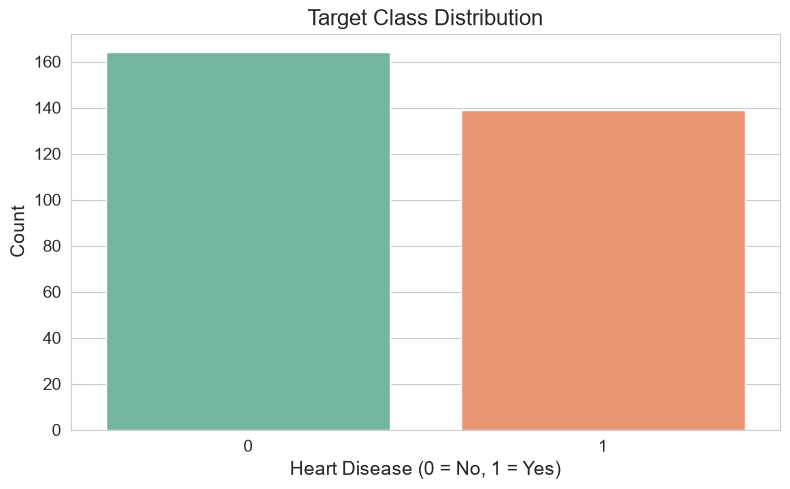

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Target Class Distribution')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Histograms for Numerical Features
Histograms reveal the distribution shape of each numeric feature after preprocessing.

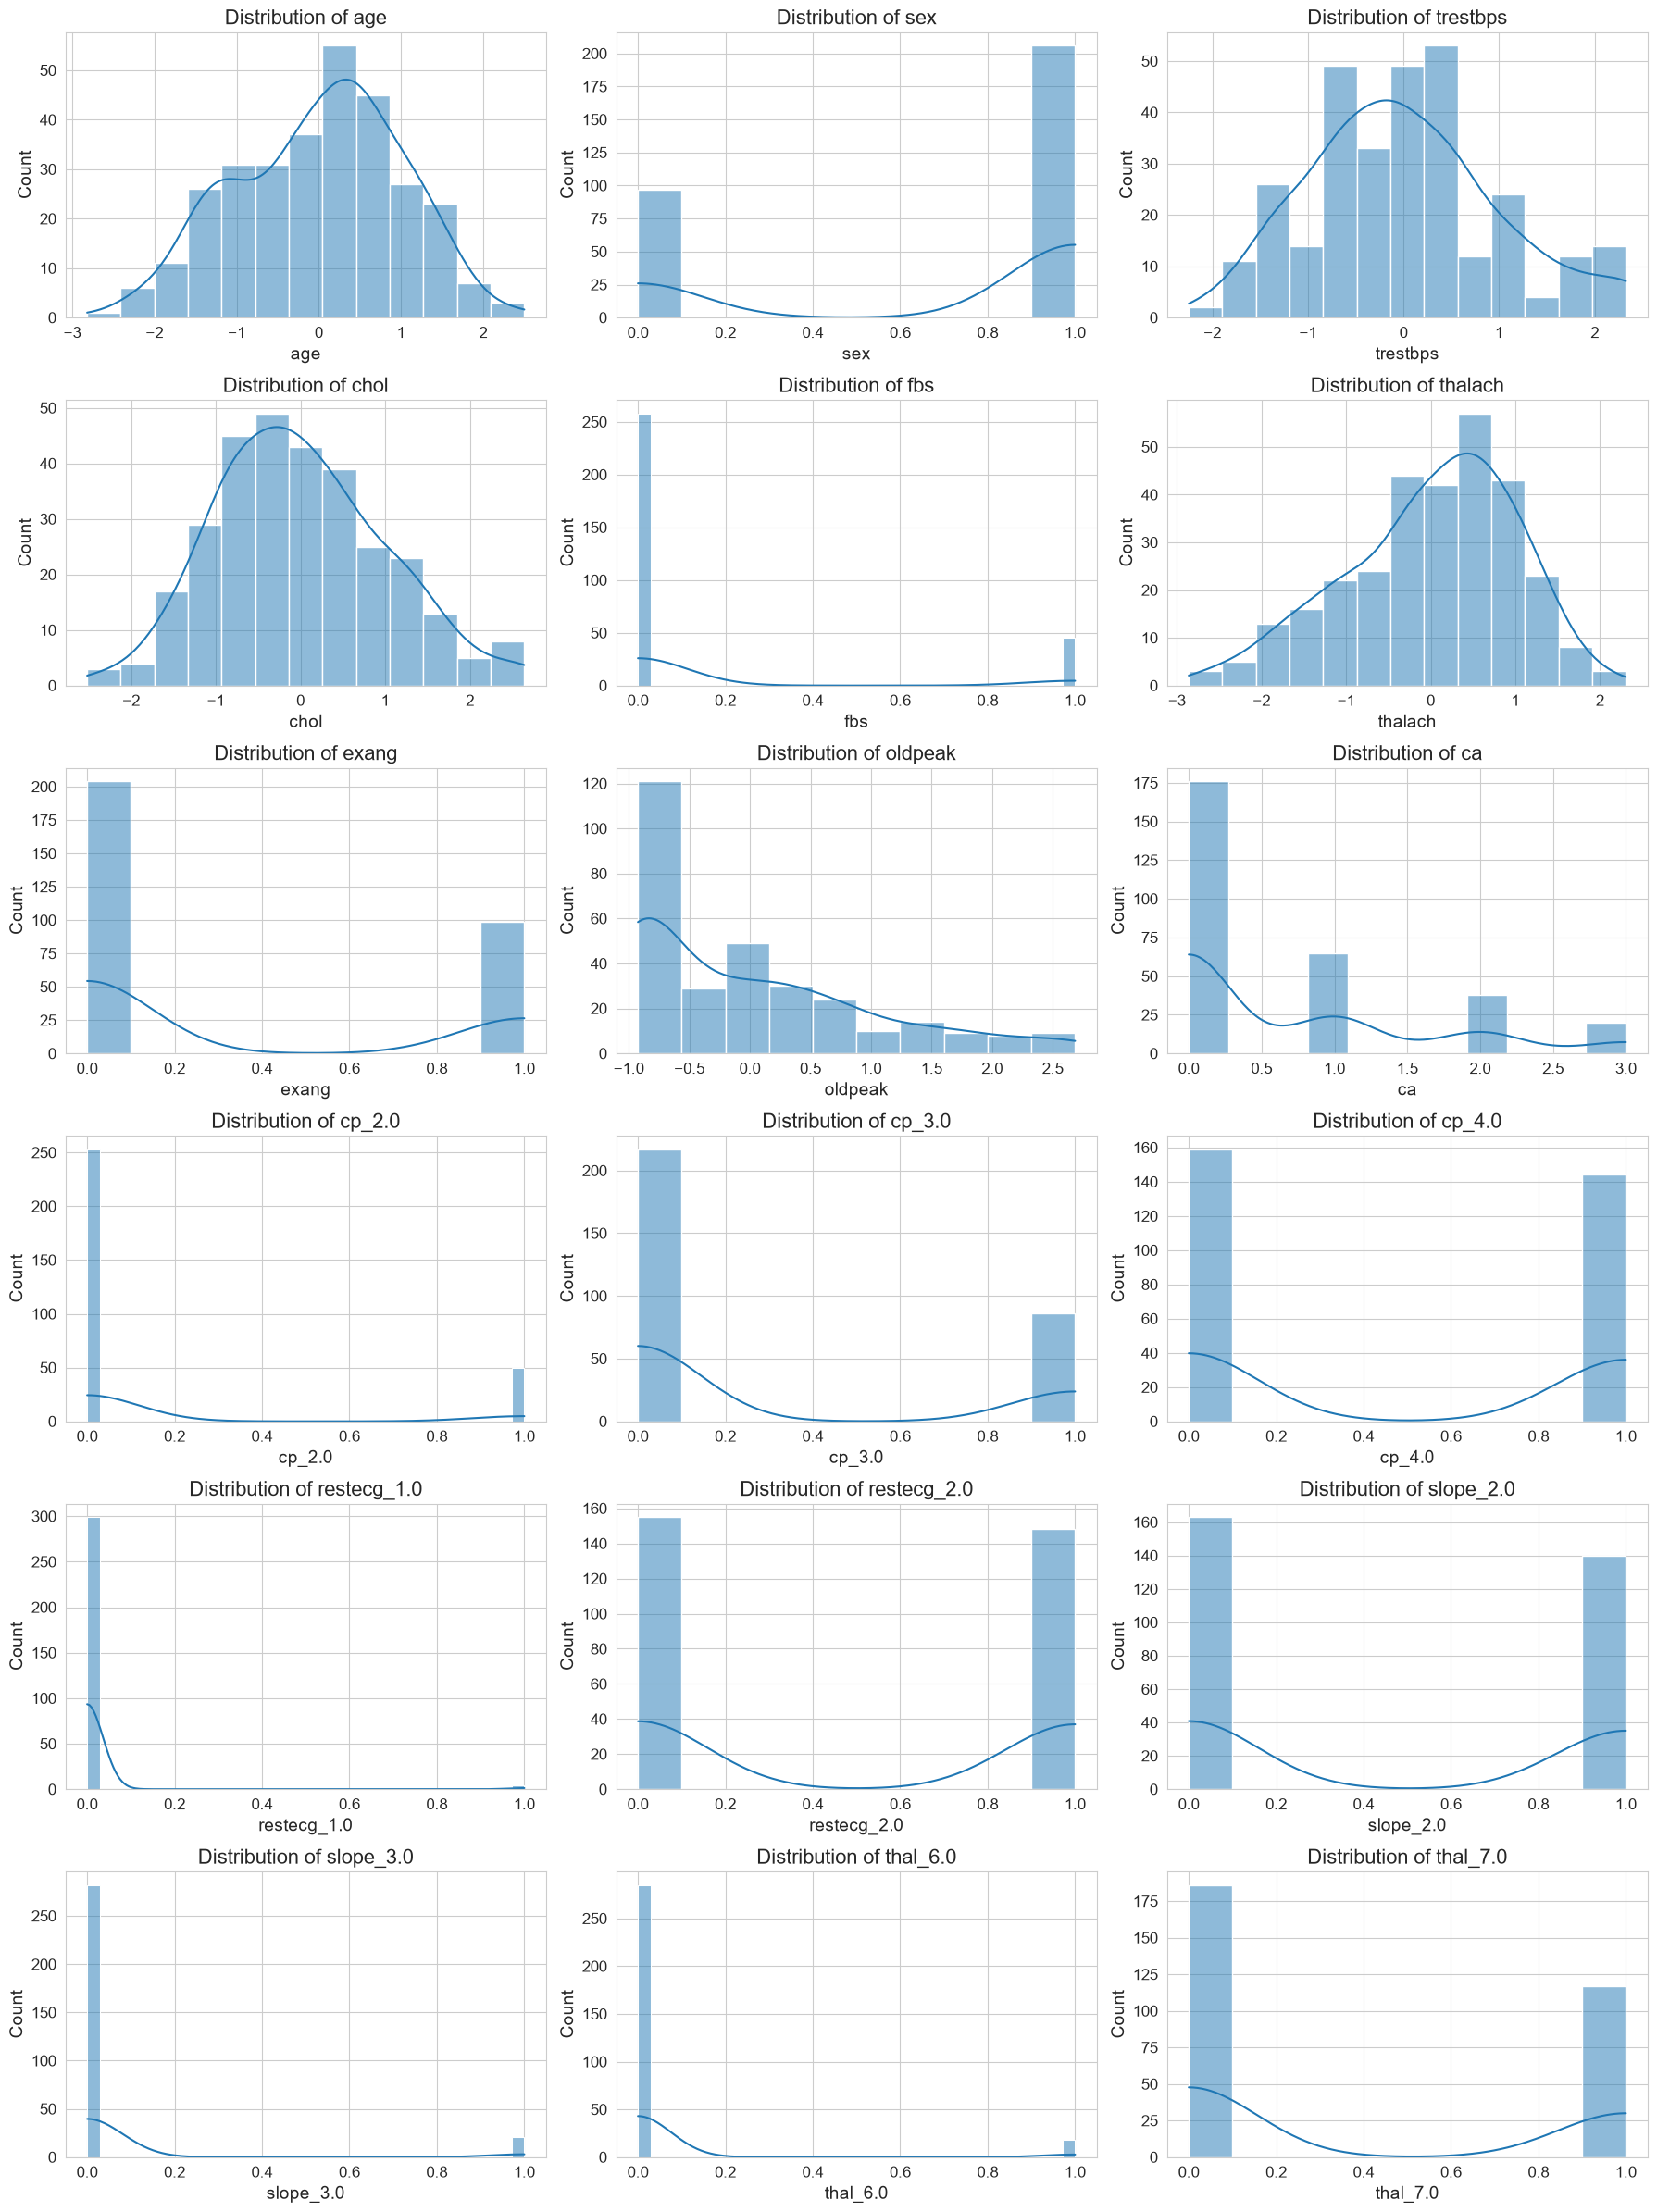

In [10]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.drop('target')
n_cols = 3
n_rows = int(np.ceil(len(numeric_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.ravel()
for idx, col in enumerate(numeric_columns):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='tab:blue')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
for idx in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[idx])
plt.tight_layout()
plt.show()

## Correlation Heatmap
The correlation heatmap highlights feature relationships and potential multicollinearity.

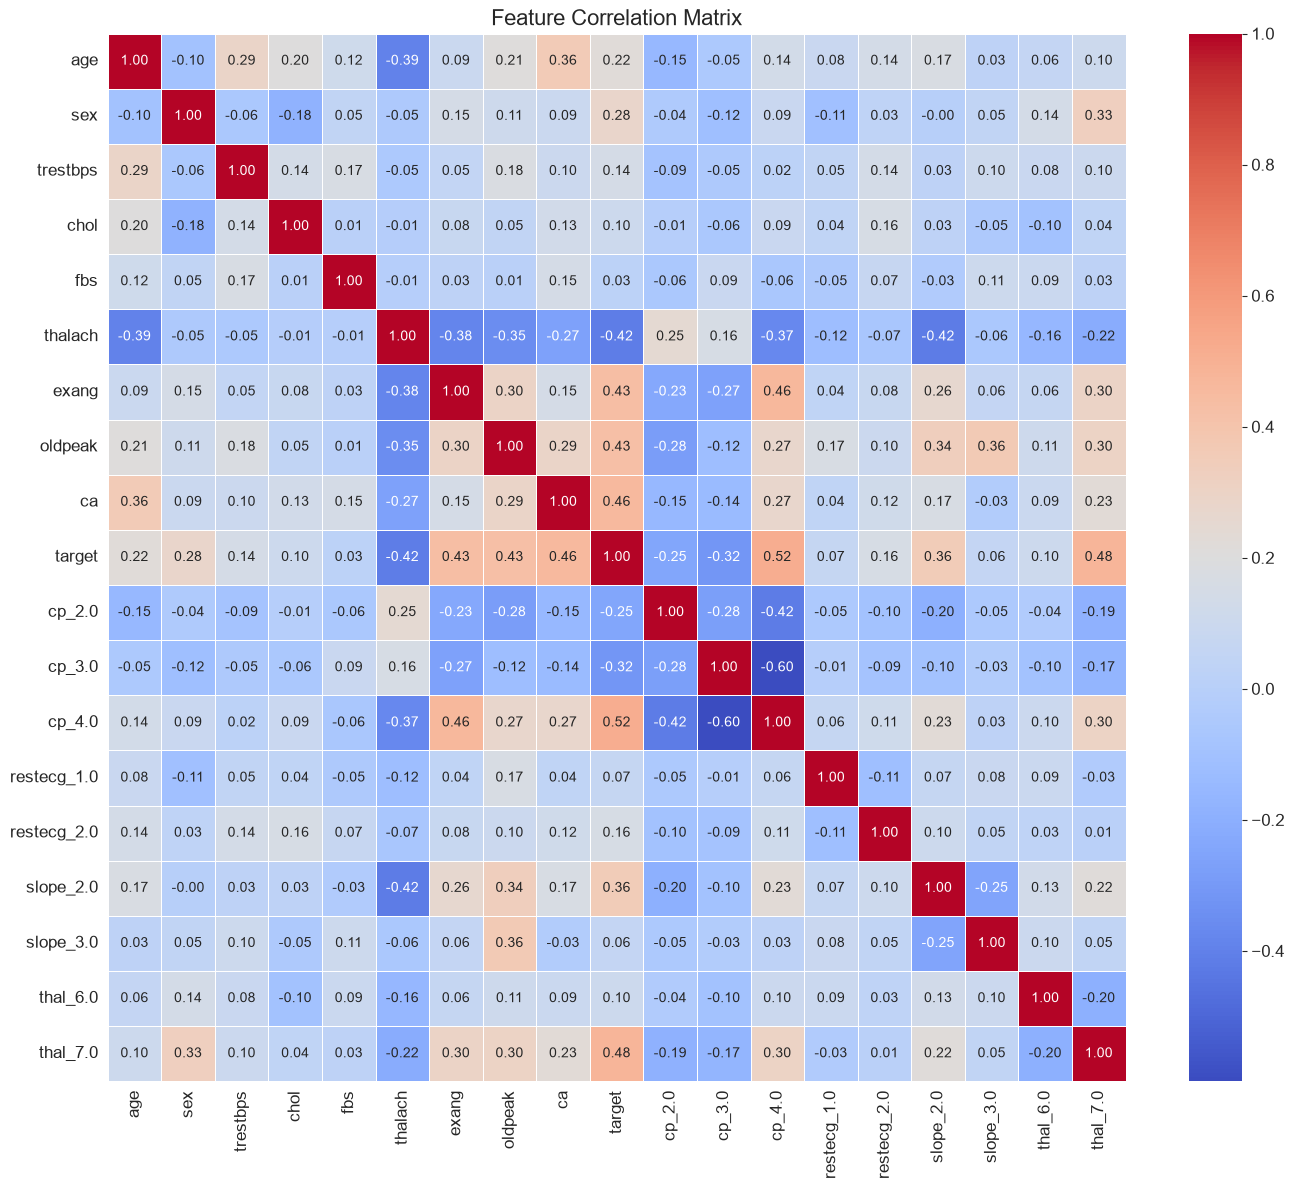

In [11]:
corr = df.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Boxplots for Numerical Features
Boxplots show the range and presence of outliers for each numeric feature.

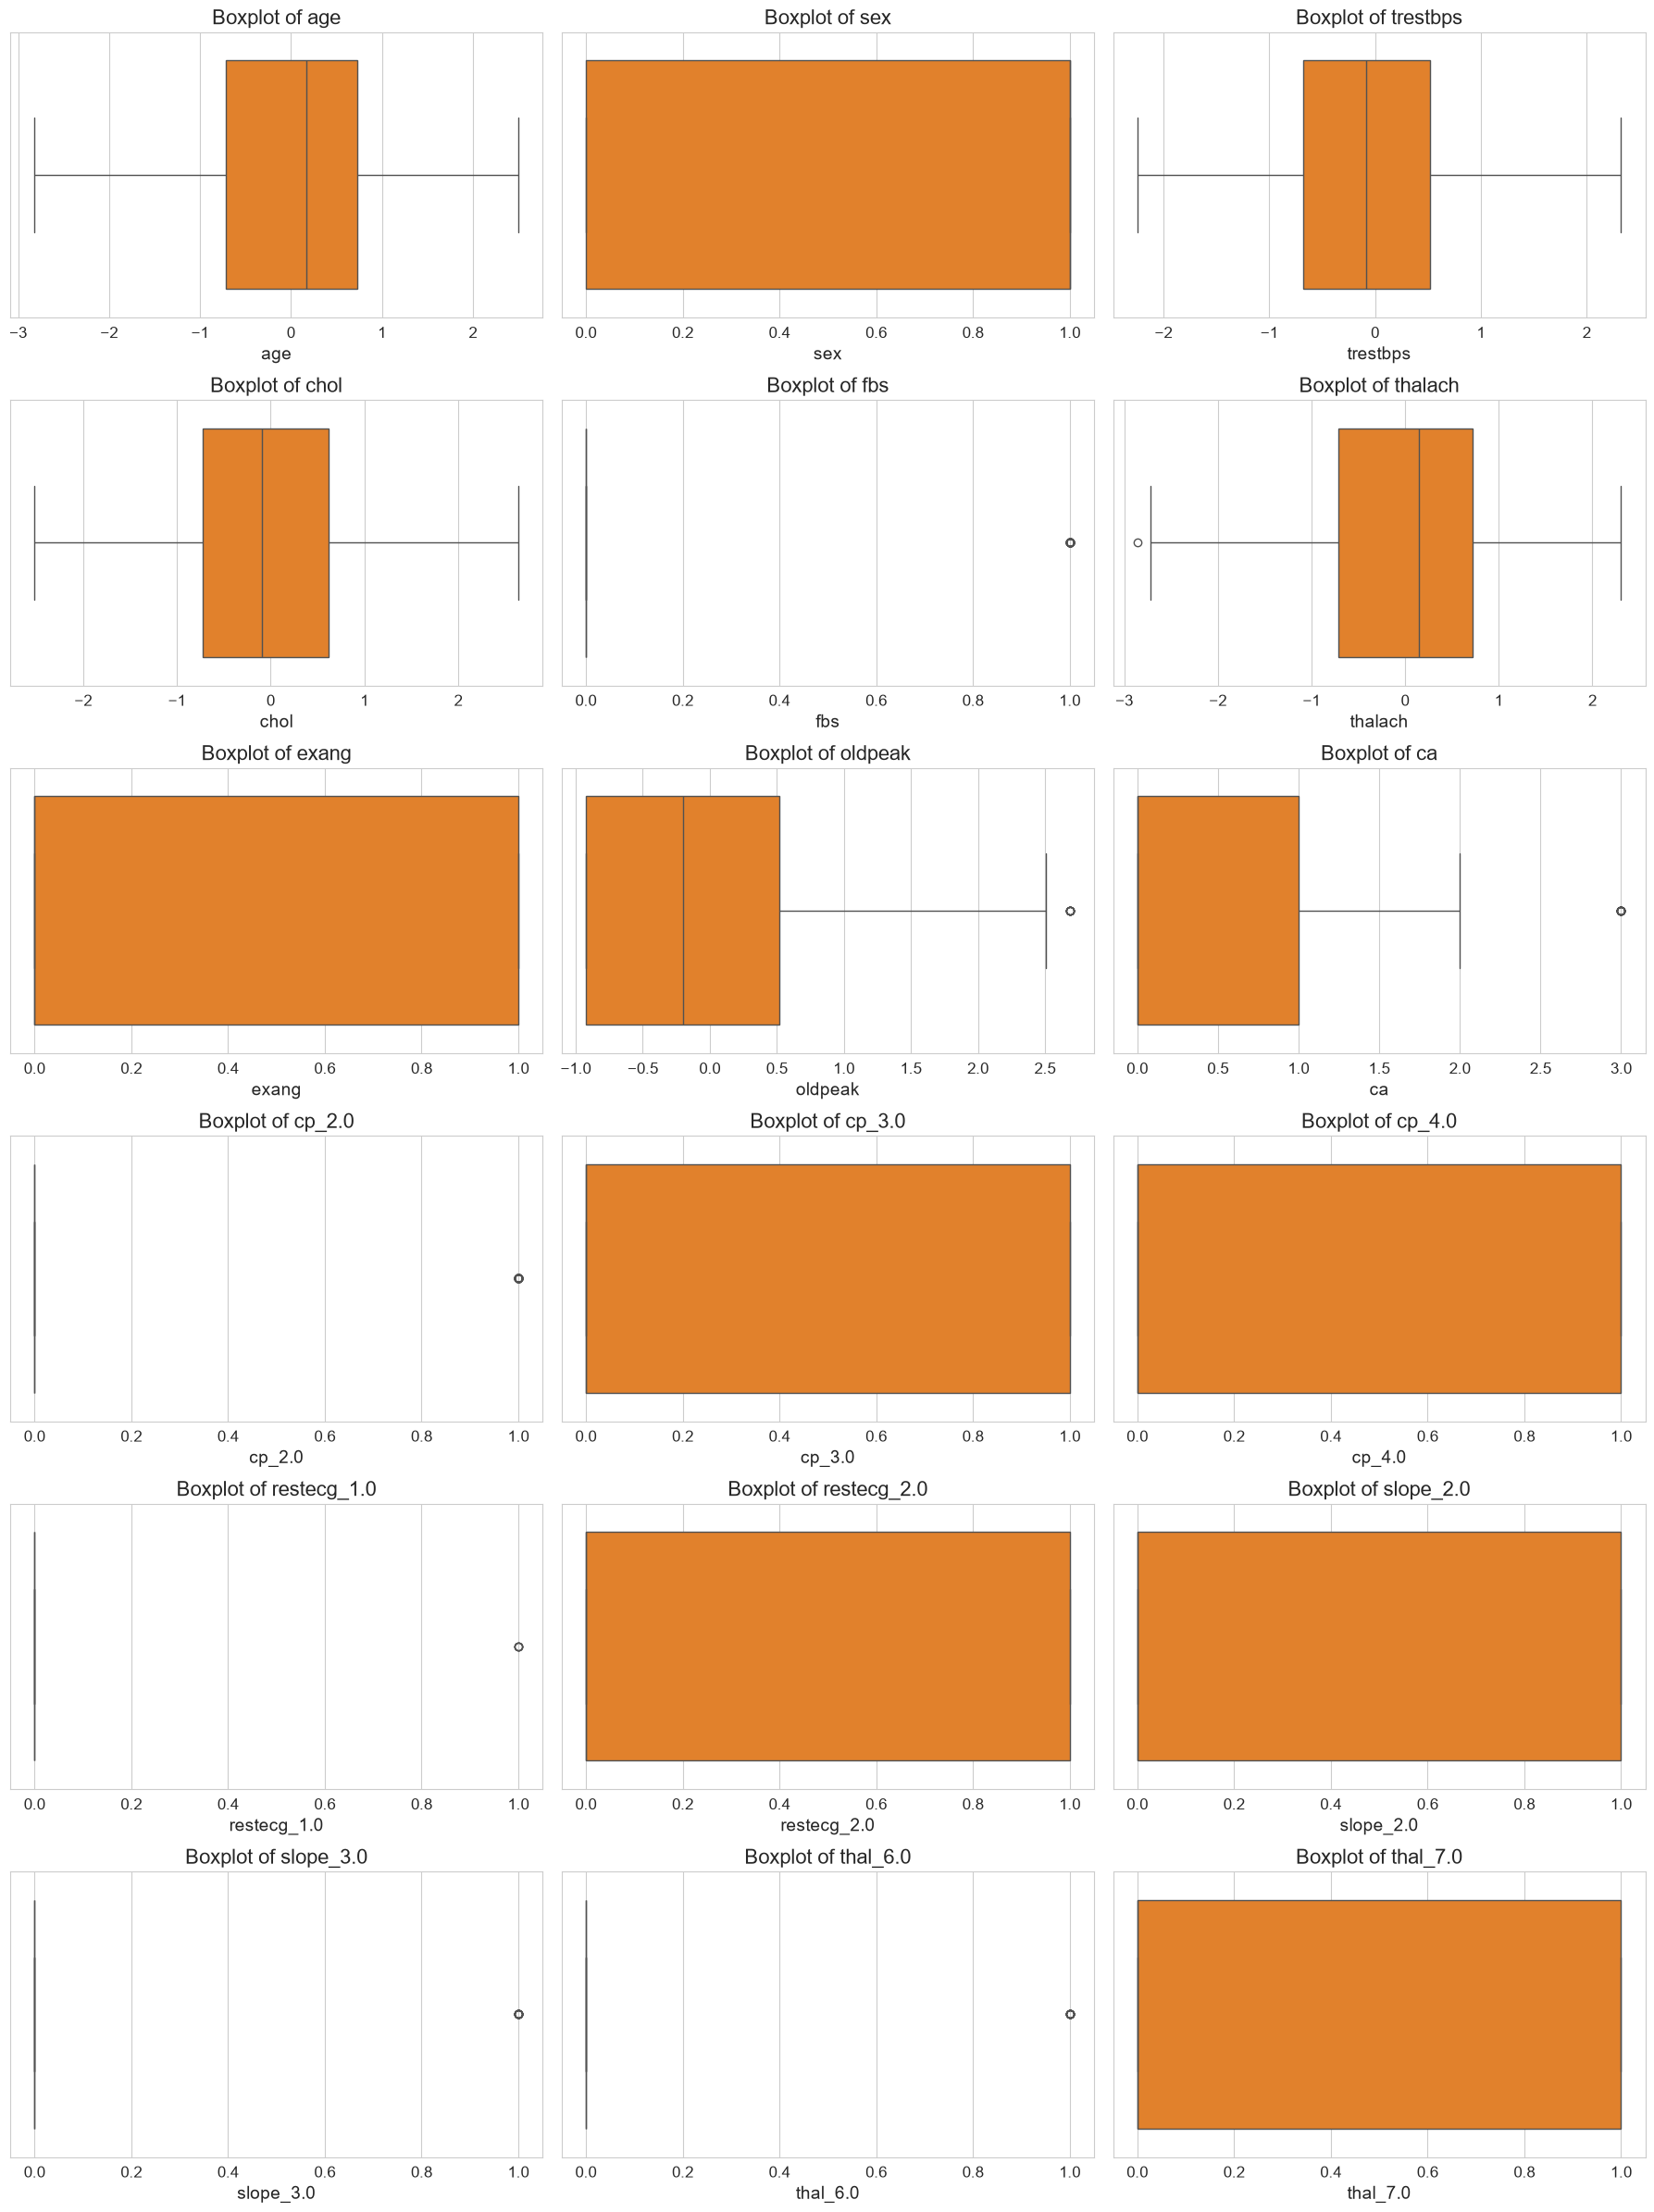

In [12]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.ravel()
for idx, col in enumerate(numeric_columns):
    sns.boxplot(x=df[col], ax=axes[idx], color='tab:orange')
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_xlabel(col)
for idx in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[idx])
plt.tight_layout()
plt.show()

## Pairplot of Important Numerical Features
This pairplot uses the most important numerical features and visualizes their relationships colored by the target class.

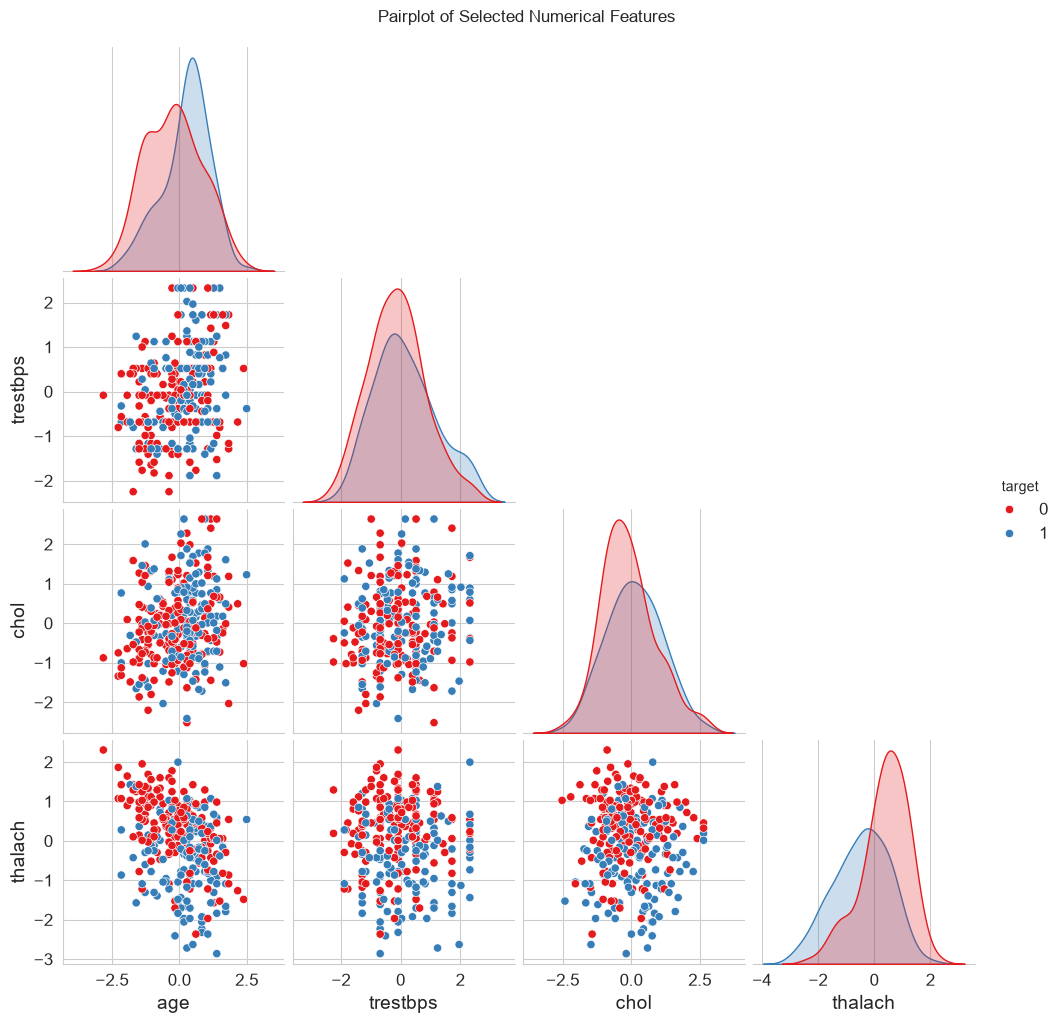

In [13]:
important_features = ['age', 'trestbps', 'chol', 'thalach']
sns.pairplot(df[important_features + ['target']], hue='target', corner=True, palette='Set1')
plt.suptitle('Pairplot of Selected Numerical Features', y=1.02)
plt.show()

## Feature vs Target Analysis
Boxplots against the target reveal how feature distributions differ between heart disease positive and negative cases.

C:\Users\Priyanka\AppData\Local\Temp\ipykernel_10368\1805900601.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[idx], palette='Set3')
C:\Users\Priyanka\AppData\Local\Temp\ipykernel_10368\1805900601.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[idx], palette='Set3')
C:\Users\Priyanka\AppData\Local\Temp\ipykernel_10368\1805900601.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[idx], palette='Set3')
C:\Users\Priyanka\AppData

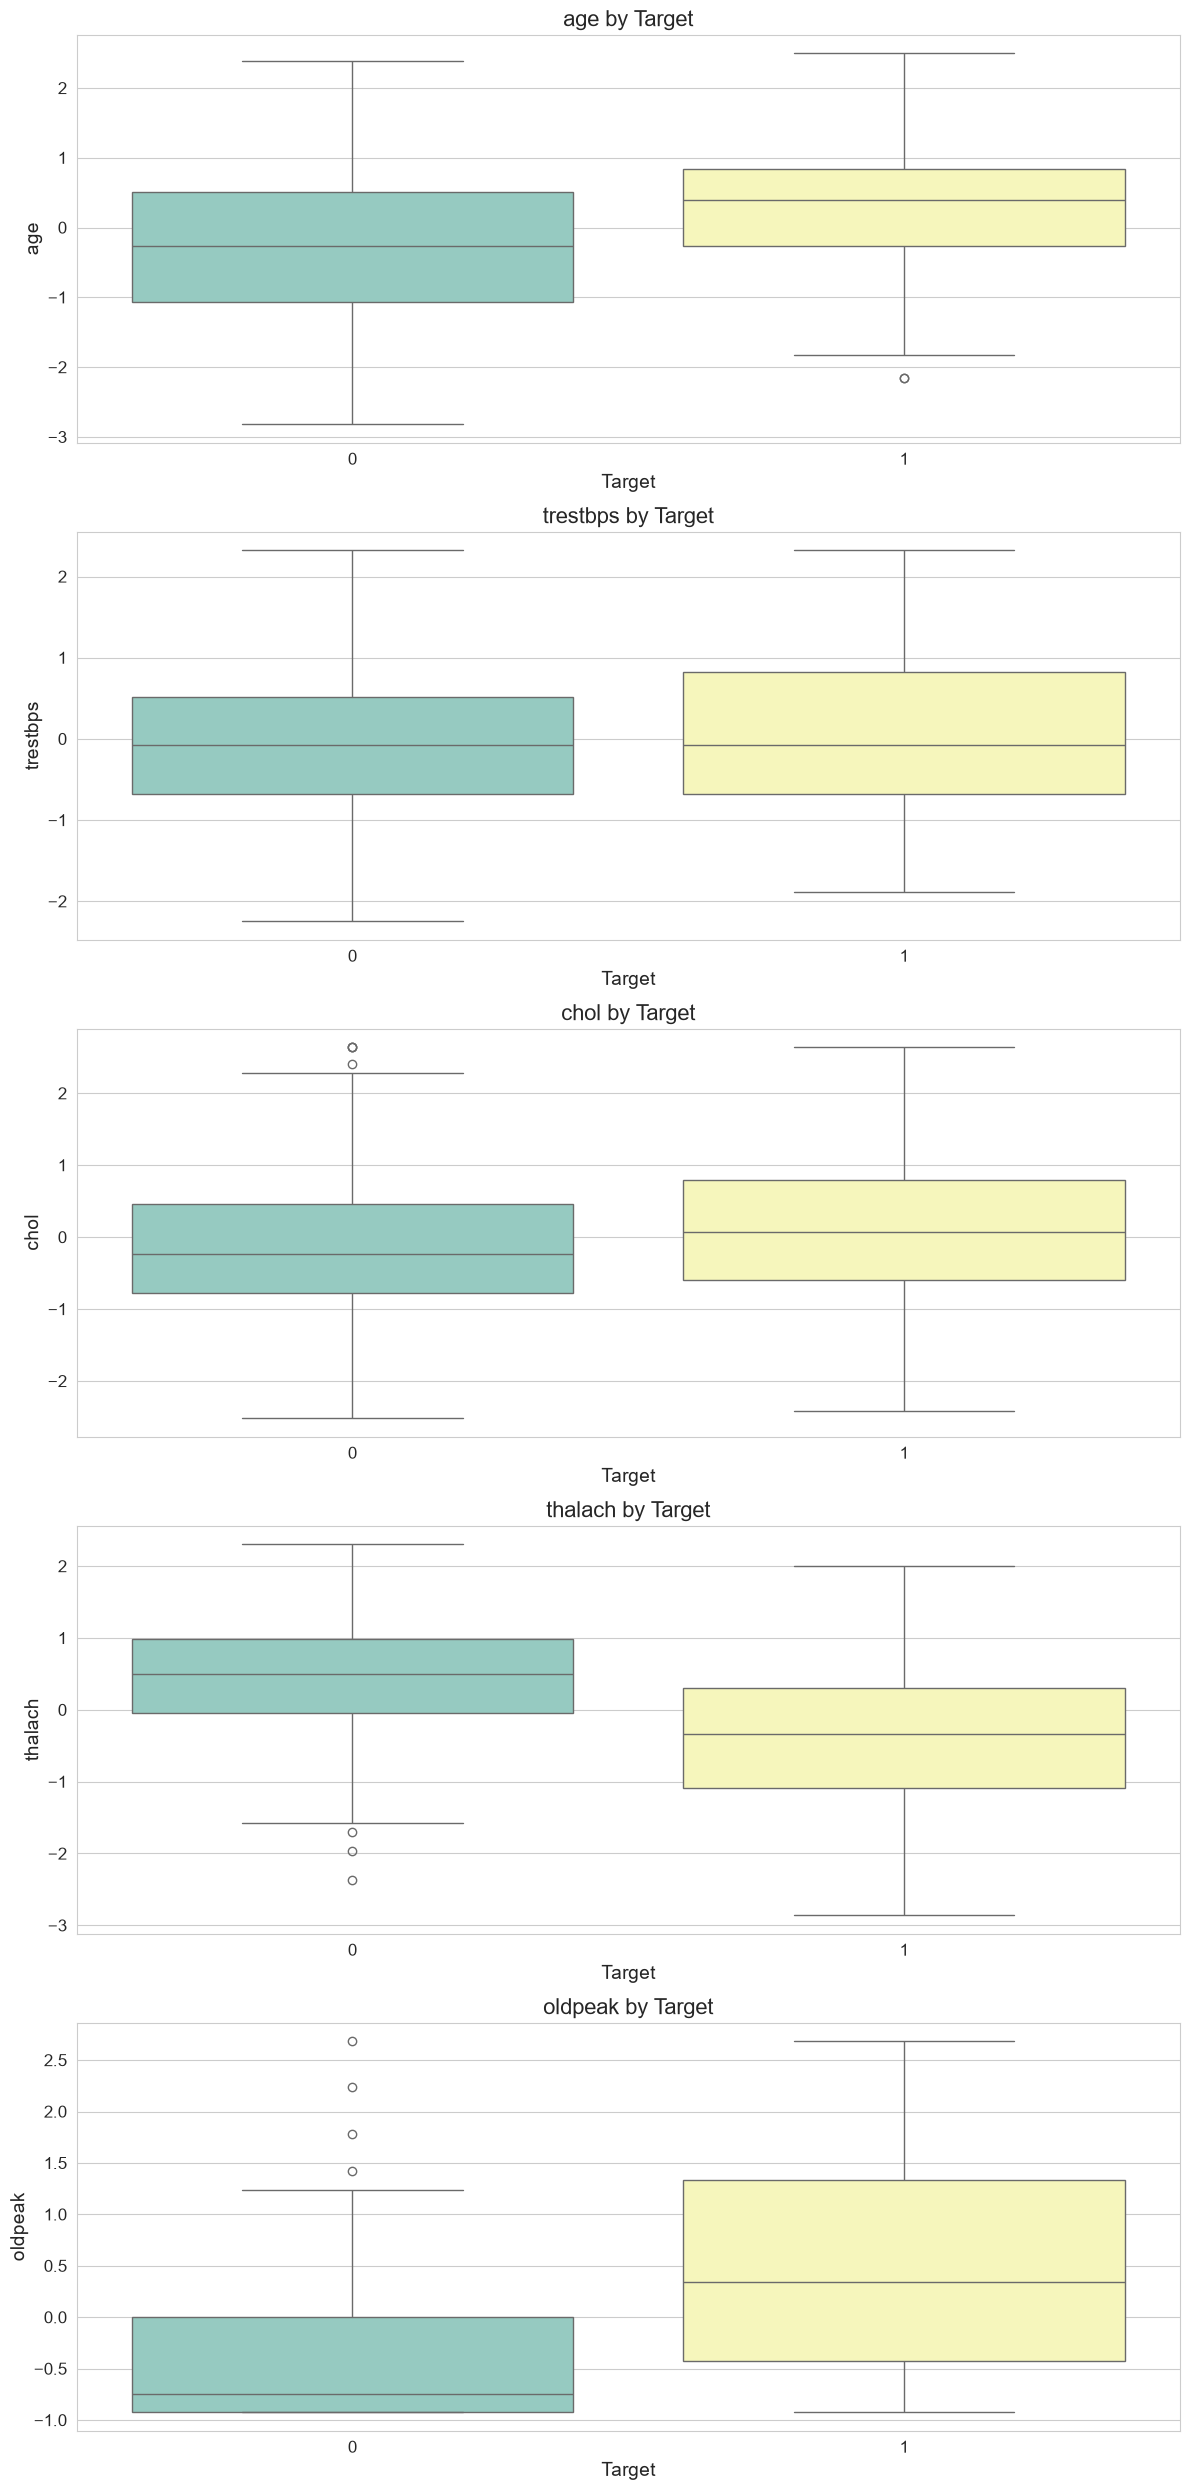

In [14]:
feature_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(len(feature_columns), 1, figsize=(12, 5 * len(feature_columns)))
for idx, col in enumerate(feature_columns):
    sns.boxplot(x='target', y=col, data=df, ax=axes[idx], palette='Set3')
    axes[idx].set_title(f'{col} by Target')
    axes[idx].set_xlabel('Target')
    axes[idx].set_ylabel(col)
plt.tight_layout()
plt.show()

## Correlation with Target
This section identifies which features have the strongest linear correlation with the target label.

In [15]:
target_corr = corr['target'].sort_values(ascending=False)
target_corr

target         1.000000
cp_4.0         0.516459
thal_7.0       0.480582
ca             0.460442
exang          0.431894
oldpeak        0.430309
slope_2.0      0.355709
sex            0.276816
age            0.223120
restecg_2.0    0.160400
trestbps       0.144980
thal_6.0       0.104864
chol           0.103896
restecg_1.0    0.067605
slope_3.0      0.061710
fbs            0.025264
cp_2.0        -0.248683
cp_3.0        -0.315141
thalach       -0.417624
Name: target, dtype: float64

## Final Observations
The analysis highlights the key patterns, feature relationships, and target distribution findings that will inform model selection and tuning.

- The dataset is clean and contains no missing values after preprocessing.
- The target class distribution should be reviewed for balance before selecting evaluation metrics.
- Numerical features such as `trestbps`, `chol`, and `thalach` show clear differences across target classes.
- Correlation analysis indicates which features are most strongly related to the target and should be prioritized in modeling.
- The pairplot and boxplots demonstrate useful separations between target classes that can support classification performance.